<a href="https://colab.research.google.com/github/kalindazzahra-bit/CalinaVeli-bit.github.io/blob/main/PERCOBAAN_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**𝐀𝐍𝐀𝐋𝐈𝐒𝐈𝐒 𝐏𝐄𝐑𝐒𝐄𝐁𝐀𝐑𝐀𝐍 𝐁𝐀𝐓𝐔𝐀𝐍 𝐏𝐀𝐃𝐀 𝐒𝐔𝐍𝐃𝐀 𝐀𝐑𝐂 𝐉𝐀𝐖𝐀 𝐁𝐄𝐑𝐃𝐀𝐒𝐀𝐑𝐊𝐀𝐍 𝐃𝐀𝐓𝐀 𝐆𝐄𝐎𝐊𝐈𝐌𝐈𝐀**

**TAHAP 1: Install Library**


*   Geopandas
*   Folium
*   Scikit-learn
*   Matplotlib
*   Seaborn
*   Plotly
*   Openpyxl

In [1]:
!pip install geopandas folium scikit-learn matplotlib seaborn plotly openpyxl

**TAHAP 2: IMPORT LIBRARY**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
import folium

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**TAHAP 3: UPLOAD DATASET**
*   Data Set Geokimia Sunda Arc Jawa
*   Peta Indonesia

In [3]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [4]:
from google.colab import files
uploaded = files.upload()

Saving ne_10m_admin_0_countries_idn.zip to ne_10m_admin_0_countries_idn.zip
Saving DSC01255.JPG to DSC01255.JPG


In [5]:
import os
os.listdir()

['.config',
 'DSC01255.JPG',
 'data.csv',
 'ne_10m_admin_0_countries_idn.zip',
 'sample_data']

**TAHAP 4: BACA DATA dan BERSIHKAN DATA**

In [6]:
df = pd.read_csv(
    'data.csv',
    sep=';',
    encoding='latin1',
    on_bad_lines='skip'
)

In [7]:
df.columns = df.columns.str.strip().str.upper()

df.columns

Index(['YEAR', 'CITATION', 'SAMPLE NAME', 'UNIQUE_ID', 'LOCATION',
       'ELEVATION (MIN.)', 'ELEVATION (MAX.)', 'SAMPLING TECHNIQUE',
       'DRILLING DEPTH (MIN.)', 'DRILLING DEPTH (MAX.)', 'LAND/SEA (SAMPLING)',
       'ROCK TYPE', 'ROCK NAME', 'ROCK TEXTURE', 'SAMPLE COMMENT',
       'AGE (MIN.)', 'AGE (MAX.)', 'GEOLOGICAL AGE', 'GEOLOGICAL AGE PREFIX',
       'ERUPTION DAY', 'ERUPTION MONTH', 'ERUPTION YEAR', 'ALTERATION',
       'ALTERATION TYPE', 'TYPE OF MATERIAL', 'MINERAL / COMPONENT',
       'SPOT (MINERAL)', 'CRYSTAL', 'RIM / CORE (MINERAL GRAINS)',
       'PRIMARY/SECONDARY', 'INCLUSION TYPE', 'MINERAL (INCLUSION)',
       'RIM / CORE (INCLUSION)', 'HOSTMINERAL (INCLUSION)', 'LATITUDE (MIN.)',
       'LONGITUDE (MIN.)', 'LATITUDE (MAX.)', 'LONGITUDE (MAX.)',
       'SIO2(WT%): ALTERN. VALUES OR METHODS', 'UNNAMED: 39', 'UNNAMED: 40',
       'UNNAMED: 41', 'K2O(WT%): ALTERN. VALUES OR METHODS', 'UNNAMED: 43',
       'UNNAMED: 44', 'UNNAMED: 45', 'NA2O(WT%)'],
      dtype='

In [8]:
df = df.rename(columns={
    'LATITUDE (MIN.)': 'LATITUDE',
    'LONGITUDE (MIN.)': 'LONGITUDE',
    'SIO2(WT%): altern. values or methods': 'SIO2',
    'K2O(WT%): altern. values or methods': 'K2O',
    'NA2O(WT%): altern. values or methods': 'NA2O'
})

In [9]:
for col in df.columns:
    print(repr(col))

'YEAR'
'CITATION'
'SAMPLE NAME'
'UNIQUE_ID'
'LOCATION'
'ELEVATION (MIN.)'
'ELEVATION (MAX.)'
'SAMPLING TECHNIQUE'
'DRILLING DEPTH (MIN.)'
'DRILLING DEPTH (MAX.)'
'LAND/SEA (SAMPLING)'
'ROCK TYPE'
'ROCK NAME'
'ROCK TEXTURE'
'SAMPLE COMMENT'
'AGE (MIN.)'
'AGE (MAX.)'
'GEOLOGICAL AGE'
'GEOLOGICAL AGE PREFIX'
'ERUPTION DAY'
'ERUPTION MONTH'
'ERUPTION YEAR'
'ALTERATION'
'ALTERATION TYPE'
'TYPE OF MATERIAL'
'MINERAL / COMPONENT'
'SPOT (MINERAL)'
'CRYSTAL'
'RIM / CORE (MINERAL GRAINS)'
'PRIMARY/SECONDARY'
'INCLUSION TYPE'
'MINERAL (INCLUSION)'
'RIM / CORE (INCLUSION)'
'HOSTMINERAL (INCLUSION)'
'LATITUDE'
'LONGITUDE'
'LATITUDE (MAX.)'
'LONGITUDE (MAX.)'
'SIO2(WT%): ALTERN. VALUES OR METHODS'
'UNNAMED: 39'
'UNNAMED: 40'
'UNNAMED: 41'
'K2O(WT%): ALTERN. VALUES OR METHODS'
'UNNAMED: 43'
'UNNAMED: 44'
'UNNAMED: 45'
'NA2O(WT%)'


In [10]:
df = df.rename(columns={

    'LATITUDE (MIN.)': 'LATITUDE',

    'LONGITUDE (MIN.)': 'LONGITUDE',

    'SIO2(WT%): ALTERN. VALUES OR METHODS': 'SIO2',

    'K2O(WT%): ALTERN. VALUES OR METHODS': 'K2O',

    'NA2O(WT%)': 'NA2O'

})

In [11]:
df.columns

Index(['YEAR', 'CITATION', 'SAMPLE NAME', 'UNIQUE_ID', 'LOCATION',
       'ELEVATION (MIN.)', 'ELEVATION (MAX.)', 'SAMPLING TECHNIQUE',
       'DRILLING DEPTH (MIN.)', 'DRILLING DEPTH (MAX.)', 'LAND/SEA (SAMPLING)',
       'ROCK TYPE', 'ROCK NAME', 'ROCK TEXTURE', 'SAMPLE COMMENT',
       'AGE (MIN.)', 'AGE (MAX.)', 'GEOLOGICAL AGE', 'GEOLOGICAL AGE PREFIX',
       'ERUPTION DAY', 'ERUPTION MONTH', 'ERUPTION YEAR', 'ALTERATION',
       'ALTERATION TYPE', 'TYPE OF MATERIAL', 'MINERAL / COMPONENT',
       'SPOT (MINERAL)', 'CRYSTAL', 'RIM / CORE (MINERAL GRAINS)',
       'PRIMARY/SECONDARY', 'INCLUSION TYPE', 'MINERAL (INCLUSION)',
       'RIM / CORE (INCLUSION)', 'HOSTMINERAL (INCLUSION)', 'LATITUDE',
       'LONGITUDE', 'LATITUDE (MAX.)', 'LONGITUDE (MAX.)', 'SIO2',
       'UNNAMED: 39', 'UNNAMED: 40', 'UNNAMED: 41', 'K2O', 'UNNAMED: 43',
       'UNNAMED: 44', 'UNNAMED: 45', 'NA2O'],
      dtype='object')

In [12]:
df_clean = df[[

    'SIO2',
    'K2O',
    'NA2O',
    'LATITUDE',
    'LONGITUDE'

]].copy()

In [13]:
numeric_cols = [
    'SIO2',
    'K2O',
    'NA2O',
    'LATITUDE',
    'LONGITUDE'
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors='coerce'
    )

In [14]:
df_clean = df_clean.dropna()

In [15]:
df_clean.head()

,SIO2,K2O,NA2O,LATITUDE,LONGITUDE
0,56.00,2.20,3.80,-7.533,110.433
1,49.00,0.32,2.30,-7.250,108.050
2,47.49,6.08,2.23,-7.000,114.000
3,47.75,5.28,2.77,-7.000,114.000
4,46.16,5.27,2.08,-7.000,114.000


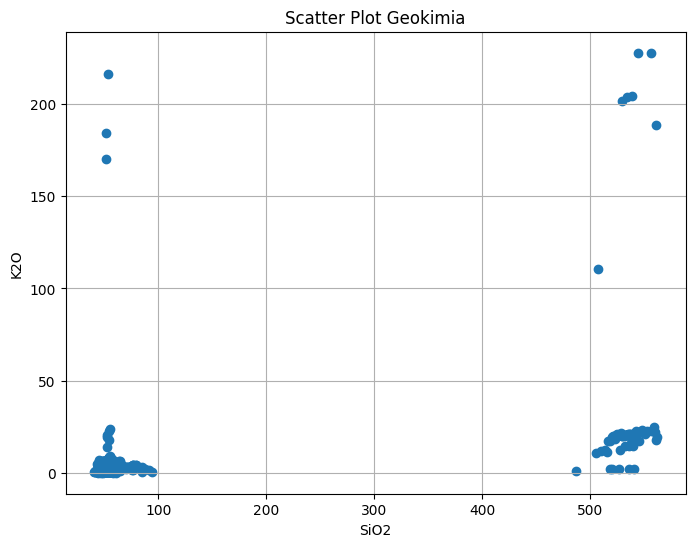

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_clean['SIO2'],
    df_clean['K2O']
)

plt.xlabel('SiO2')
plt.ylabel('K2O')

plt.title('Scatter Plot Geokimia')

plt.grid(True)

plt.show()

In [17]:
df_clean[['SIO2', 'K2O', 'NA2O']].describe()

,SIO2,K2O,NA2O
count,1123.000000,1123.000000,1123.000000
mean,83.797603,4.681655,8.717698
std,116.568449,18.678280,36.625161
min,40.210000,0.010000,0.010000
25%,50.795000,1.050000,2.900000
50%,53.930000,1.840000,3.290000
75%,56.790000,2.720000,3.730000
max,562.518000,227.855000,383.105000


In [18]:
df_clean.sort_values('SIO2').head(10)
df_clean.sort_values('SIO2', ascending=False).head(10)

,SIO2,K2O,NA2O,LATITUDE,LONGITUDE
870,562.518,19.305,35.244,-7.533,110.433
824,561.358,188.575,383.105,-7.533,110.433
864,560.782,17.711,361.185,-7.533,110.433
887,560.439,21.978,36.828,-7.533,110.433
966,558.954,24.651,37.818,-7.533,110.433
798,558.756,22.473,3.762,-7.533,110.433
802,556.404,227.855,369.145,-7.533,110.433
803,556.083,22.374,38.511,-7.533,110.433
815,552.717,22.671,3.762,-7.533,110.433
800,552.123,22.077,38.313,-7.533,110.433


In [19]:
df_geo = df_clean[
    (df_clean['SIO2'].between(35, 80)) &
    (df_clean['K2O'].between(0, 15)) &
    (df_clean['NA2O'].between(0, 15))
].copy()

**ANALISIS SCATTER PLOT GEOKIMIA**

Sebagian besar data terkonsentrasi pada:


*   SiO₂ ≈ 48–60 wt%
*   Na₂O + K₂O ≈ 3–8 wt%

Persebaran tersebut menunjukkan bahwa di Pulau Jawa didominasi oleh batu basalt, basaltic andesite, dan andesite, sehingga mengindikasikan magma berkomposisi intermediate. Pola ini juga menunjukkan karakter magma calc-alkali yang umum pada zona subduksi dan sistem vulkanik Pulau Jawa didominasi magma hasil aktivitas busur vulkanik (volcanic arc).


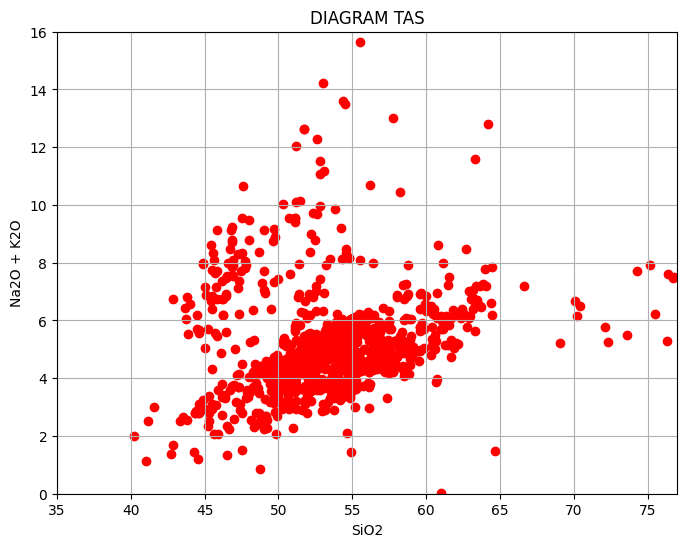

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(

    df_geo['SIO2'],

    df_geo['NA2O'] + df_geo['K2O'],

    c='red'

)

plt.xlabel('SiO2')

plt.ylabel('Na2O + K2O')

plt.title('DIAGRAM TAS')

plt.grid(True)

plt.xlim(35,77)
plt.ylim(0,16)

plt.xlabel('SiO2')
plt.ylabel('Na2O + K2O')

plt.title('DIAGRAM TAS')

plt.grid(True)

plt.show()

plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
features = df_geo[['SIO2', 'K2O', 'NA2O']]

In [23]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [24]:
from sklearn.cluster import KMeans

In [25]:
inertia = []

k_range = range(1, 11)

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(scaled_features)

    inertia.append(km.inertia_)

**ANALISIS ELBOW METHOD**

Grafik Elbow Method menunjukkan hubungan antara jumlah cluster (K) dan nilai inertia.Nilai inertia terus menurun seiring bertambahnya jumlah cluster karena data menjadi semakin terbagi ke dalam kelompok yang lebih kecil.
Penurunan inertia paling signifikan terjadi pada:
*   K = 1 → 2

*   K = 2 → 3

*   K = 3 → 4

Setelah K = 4, penurunan inertia mulai melandai sehingga tambahan cluster tidak lagi memberikan peningkatan yang signifikan terhadap kualitas clustering.
Titik siku (elbow point) terlihat berada pada K ≈ 4 sehingga jumlah cluster optimal dipilih sebanyak 4 cluster. Hal ini menunjukkan bahwa data geokimia vulkanik memiliki sekitar empat kelompok utama dengan karakteristik kimia yang berbeda. Pemilihan K = 4 dianggap paling optimal karena mampu merepresentasikan variasi data dengan baik tanpa membuat model terlalu kompleks.

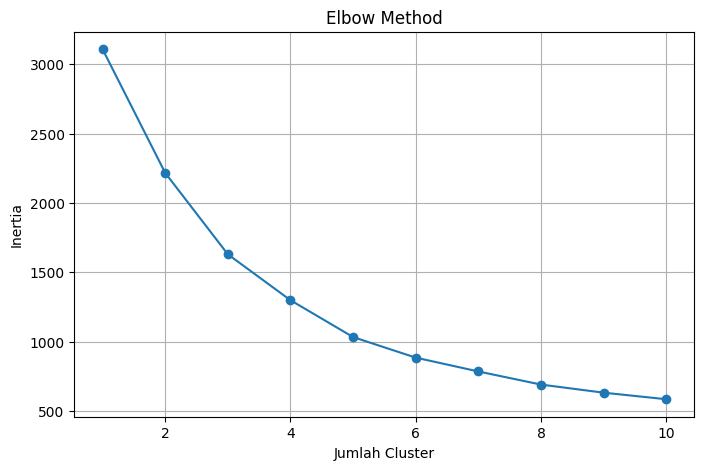

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    inertia,
    marker='o'
)

plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.grid(True)

plt.show()

In [27]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [28]:
df_geo['CLUSTER'] = kmeans.fit_predict(
    scaled_features
)

In [29]:
df_geo.head()

,SIO2,K2O,NA2O,LATITUDE,LONGITUDE,CLUSTER
0,56.00,2.20,3.80,-7.533,110.433,3
1,49.00,0.32,2.30,-7.250,108.050,1
2,47.49,6.08,2.23,-7.000,114.000,0
3,47.75,5.28,2.77,-7.000,114.000,0
4,46.16,5.27,2.08,-7.000,114.000,0


In [30]:
df_geo['CLUSTER'].value_counts()

,count
CLUSTER,
3,498
1,414
0,103
2,21


**INTERPRETASI PLOT CLUSTERING**


*   Cluster biru → dominan SiO₂ rendah & K₂O rendah → magma basaltik
*   Cluster merah → K₂O lebih tinggi → magma lebih evolved

*   Cluster hijau → alkali tinggi → kemungkinan diferensiasi lebih lanjut
*   Cluster ungu → SiO₂ lebih tinggi → andesitik hingga dacitik

Artinya:
K-Means berhasil memisahkan populasi geokimia magma berdasarkan karakter kimianya.

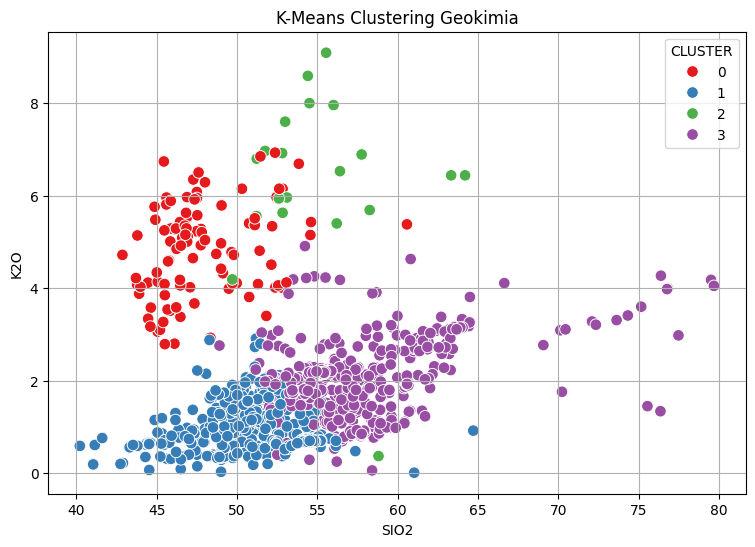

In [31]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df_geo,
    x='SIO2',
    y='K2O',
    hue='CLUSTER',
    palette='Set1',
    s=70
)

plt.title('K-Means Clustering Geokimia')

plt.grid(True)

plt.show()

In [32]:
from sklearn.decomposition import PCA

In [33]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(
    scaled_features
)

In [34]:
df_geo['PCA1'] = pca_result[:,0]
df_geo['PCA2'] = pca_result[:,1]

**INTERPRETASI PCA PLOT**

*   Cluster terlihat cukup terpisah → clustering berhasil
Cluster merah & hijau memiliki karakter geokimia berbeda signifikan
*   Cluster merah & hijau memiliki karakter geokimia berbeda signifikan
*   Cluster biru dan ungu lebih berdekatan → karakter geokimianya lebih mirip

Artinya:
PCA berhasil menunjukkan variasi utama data geokimia vulkanik secara visual.



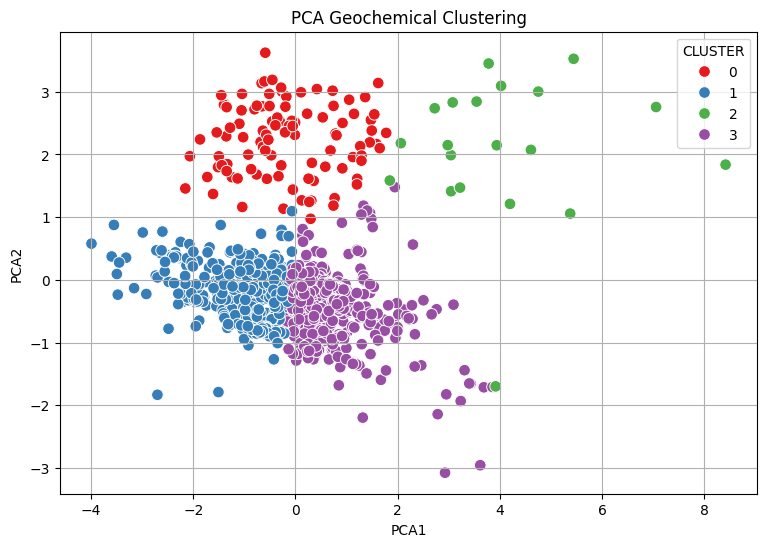

In [35]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df_geo,
    x='PCA1',
    y='PCA2',
    hue='CLUSTER',
    palette='Set1',
    s=70
)

plt.title('PCA Geochemical Clustering')

plt.grid(True)

plt.show()

In [36]:
df_geo.groupby('CLUSTER')[
    ['SIO2', 'K2O', 'NA2O']
].mean()

,SIO2,K2O,NA2O
CLUSTER,,,
0,47.905146,4.821117,2.754660
1,50.721471,1.024461,2.792580
2,55.012857,6.377952,5.999524
3,57.085562,2.050651,3.572952


In [37]:
df_geo.groupby('CLUSTER')[
    ['SIO2', 'K2O', 'NA2O']
].agg(['mean', 'min', 'max'])

SIO2                     K2O                   NA2O             
              mean    min    max      mean   min    max      mean   min    max
CLUSTER                                                                       
0        47.905146  42.86  60.57  4.821117  2.79  6.930  2.754660  0.91   4.18
1        50.721471  40.21  64.70  1.024461  0.01  2.910  2.792580  0.01   4.12
2        55.012857  49.70  64.19  6.377952  0.37  9.091  5.999524  4.56  10.68
3        57.085562  48.90  79.68  2.050651  0.06  4.910  3.572952  1.43   5.08

**ANALISIS HEATMAP KORELASI UNSUR GEOKIMIA**
Nilai korelasi berada pada rentang:
−1≤r≤1

di mana:

*   mendekati 1 → korelasi positif kuat
*   mendekati 0 → hubungan lemah
*   mendekati -1 → korelasi negatif kuat

Korelasi antara SiO₂ dan K₂O sebesar sekitar 0.066 menunjukkan hubungan yang sangat lemah. Artinya kenaikan kandungan silika tidak selalu diikuti kenaikan K₂O secara signifikan. Hal ini mengindikasikan variasi magma yang cukup kompleks.

Korelasi antara SiO₂ dan Na₂O sebesar sekitar 0.42 menunjukkan korelasi positif sedang. Semakin tinggi SiO₂, kandungan Na₂O cenderung meningkat. Pola ini umum terjadi pada proses diferensiasi magma.

Korelasi antara K₂O dan Na₂O sebesar sekitar 0.32 juga menunjukkan hubungan positif lemah hingga sedang. Kedua unsur alkali memiliki kecenderungan meningkat bersama, tetapi tidak terlalu kuat.

Tidak terdapat korelasi negatif kuat pada data. Hal ini menunjukkan bahwa unsur-unsur geokimia dalam dataset masih berkembang dalam tren kimia yang relatif searah. Warna merah pada diagonal heatmap menunjukkan korelasi sempurna bernilai 1 karena unsur dibandingkan dengan dirinya sendiri.

Secara umum, heatmap menunjukkan bahwa:
Na₂O memiliki hubungan yang lebih jelas terhadap SiO₂ dibanding K₂O.
Variasi geokimia batuan vulkanik Jawa dipengaruhi oleh lebih dari satu proses magmatik. Data memiliki heterogenitas geokimia yang mendukung hasil clustering sebelumnya.


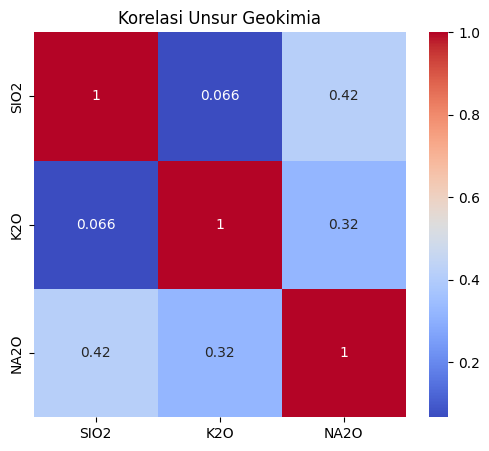

In [38]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df_geo[['SIO2','K2O','NA2O']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Korelasi Unsur Geokimia')

plt.show()

In [39]:
import geopandas as gpd

In [40]:
indo = gpd.read_file(
    'ne_10m_admin_0_countries_idn.zip'
)

In [41]:
print(indo.columns)

Index(['ADM0_A3_ID', 'featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT',
       'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)


In [42]:
indo_idn = indo[indo['ADMIN'].str.contains('Indonesia', na=False)]

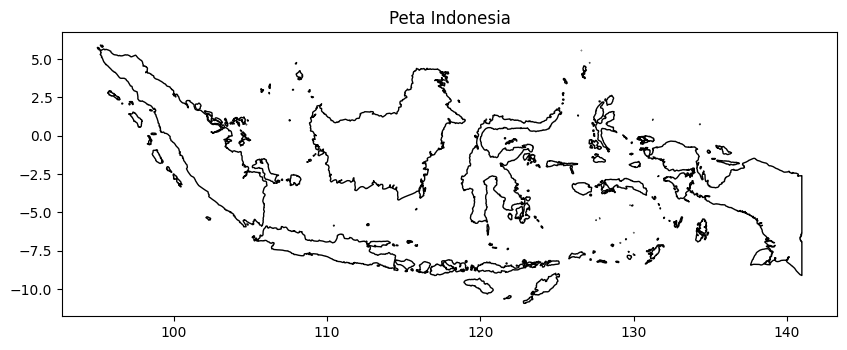

In [43]:
ax = indo_idn.plot(figsize=(10,10), edgecolor='black', color='white')
plt.title('Peta Indonesia')
plt.show()

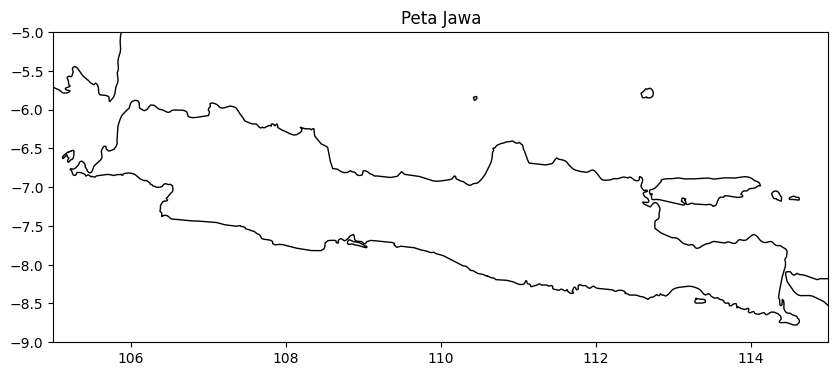

In [44]:
ax = indo_idn.plot(figsize=(10,10), edgecolor='black', color='white')
plt.xlim(105, 115)
plt.ylim(-9, -5)
plt.title('Peta Jawa')
plt.show()

In [45]:
gdf_points = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(
        df_geo['LONGITUDE'],
        df_geo['LATITUDE']
    ),
    crs='EPSG:4326'
)

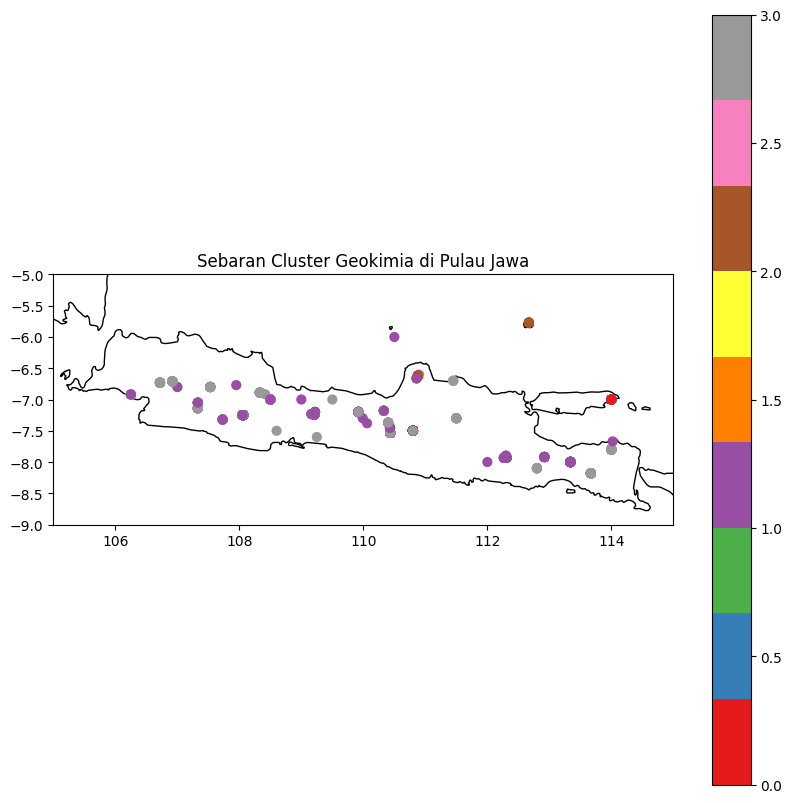

In [46]:
ax = indo_idn.plot(figsize=(10,10), edgecolor='black', color='white')
gdf_points.plot(
    ax=ax,
    column='CLUSTER',
    cmap='Set1',
    legend=True,
    markersize=40
)

plt.xlim(105, 115)
plt.ylim(-9, -5)
plt.title('Sebaran Cluster Geokimia di Pulau Jawa')
plt.show()

In [47]:
import folium

In [48]:
m = folium.Map(
    location=[-7.5, 110],
    zoom_start=7
)

In [49]:
cluster_colors = {
    0: 'red',
    1: 'blue',
    2: 'green',
    3: 'orange',
    4: 'purple'
}

In [50]:
for _, row in df_geo.iterrows():

    color = cluster_colors.get(
        row['CLUSTER'],
        'black'
    )

    popup_text = f"""
    Cluster: {row['CLUSTER']}<br>
    SiO2: {row['SIO2']}<br>
    K2O: {row['K2O']}<br>
    Na2O: {row['NA2O']}
    """

    folium.CircleMarker(
        location=[
            row['LATITUDE'],
            row['LONGITUDE']
        ],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=popup_text
    ).add_to(m)

In [51]:
m

In [52]:
m.save('peta_geokimia_jawa.html')

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [54]:
X = df_geo[['SIO2', 'K2O', 'NA2O']]
y = df_geo['CLUSTER']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [57]:
y_pred = rf.predict(X_test)

In [58]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

Accuracy: 0.9711538461538461


In [59]:
importance = rf.feature_importances_

feature_names = X.columns

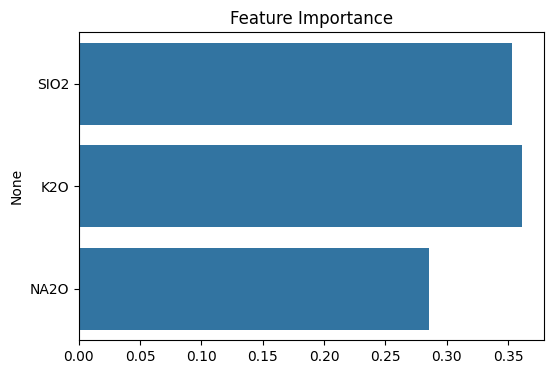

In [60]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=importance,
    y=feature_names
)

plt.title('Feature Importance')

plt.show()

In [61]:
df_geo.to_csv(
    'hasil_project_geokimia_jawa.csv',
    index=False
)

In [62]:
df_geo.groupby('CLUSTER')[
    ['SIO2', 'K2O', 'NA2O']
].mean()

,SIO2,K2O,NA2O
CLUSTER,,,
0,47.905146,4.821117,2.754660
1,50.721471,1.024461,2.792580
2,55.012857,6.377952,5.999524
3,57.085562,2.050651,3.572952


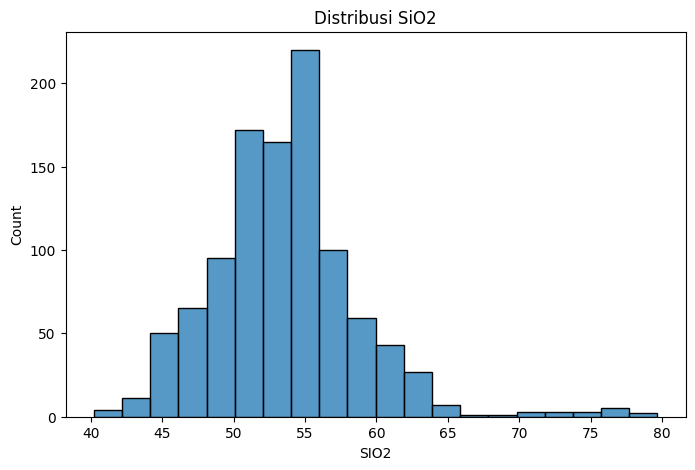

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_geo['SIO2'],
    bins=20
)

plt.title('Distribusi SiO2')

plt.show()

In [64]:
for col in df.columns:
    print(col)

YEAR
CITATION
SAMPLE NAME
UNIQUE_ID
LOCATION
ELEVATION (MIN.)
ELEVATION (MAX.)
SAMPLING TECHNIQUE
DRILLING DEPTH (MIN.)
DRILLING DEPTH (MAX.)
LAND/SEA (SAMPLING)
ROCK TYPE
ROCK NAME
ROCK TEXTURE
SAMPLE COMMENT
AGE (MIN.)
AGE (MAX.)
GEOLOGICAL AGE
GEOLOGICAL AGE PREFIX
ERUPTION DAY
ERUPTION MONTH
ERUPTION YEAR
ALTERATION
ALTERATION TYPE
TYPE OF MATERIAL
MINERAL / COMPONENT
SPOT (MINERAL)
CRYSTAL
RIM / CORE (MINERAL GRAINS)
PRIMARY/SECONDARY
INCLUSION TYPE
MINERAL (INCLUSION)
RIM / CORE (INCLUSION)
HOSTMINERAL (INCLUSION)
LATITUDE
LONGITUDE
LATITUDE (MAX.)
LONGITUDE (MAX.)
SIO2
UNNAMED: 39
UNNAMED: 40
UNNAMED: 41
K2O
UNNAMED: 43
UNNAMED: 44
UNNAMED: 45
NA2O


In [65]:
df = df.rename(columns={
    'LOCATION': 'VOLCANO'
})

In [66]:
df_geo['VOLCANO'] = df['VOLCANO']

In [67]:
df_geo['VOLCANO'].unique()[:20]

array(['SUNDA ARC / SUNDA ARC / JAVA / MERAPI',
       'SUNDA ARC / SUNDA ARC / JAVA / GALUNGGUNG',
       'SUNDA ARC / SUNDA ARC / JAVA / RINGGIT-BESAR',
       'SUNDA ARC / SUNDA ARC / JAVA / MURIAH',
       'SUNDA ARC / SUNDA ARC / JAVA / LASEM',
       'SUNDA ARC / SUNDA ARC / JAVA / PAPANDAYAN',
       'SUNDA ARC / SUNDA ARC / JAVA / GUNTUR',
       'SUNDA ARC / SUNDA ARC / JAVA / TJERIMAI (TJAREME)',
       'SUNDA ARC / SUNDA ARC / JAVA / SLAMET',
       'SUNDA ARC / SUNDA ARC / JAVA / SUNDORO',
       'SUNDA ARC / SUNDA ARC / JAVA / SUMBING',
       'SUNDA ARC / SUNDA ARC / JAVA / TANGKUBAN PARAHU',
       'SUNDA ARC / SUNDA ARC / JAVA / MERBABU',
       'SUNDA ARC / SUNDA ARC / JAVA / UNGARAN',
       'SUNDA ARC / SUNDA ARC / JAVA / BAYAH DOME',
       'SUNDA ARC / SUNDA ARC / JAVA / LAMONGAN',
       'SUNDA ARC / SUNDA ARC / JAVA / SEMERU',
       'SUNDA ARC / SUNDA ARC / JAVA / BROMO',
       'SUNDA ARC / SUNDA ARC / JAVA / DIENG VOLCANIC COMPLEX',
       'SUNDA ARC / SUNDA A

In [68]:
for _, row in df_geo.iterrows():

    folium.Marker(
        location=[
            row['LATITUDE'],
            row['LONGITUDE']
        ],

        popup=f"""
        <b>Lokasi:</b> {row['VOLCANO']}<br>
        <b>Cluster:</b> {row['CLUSTER']}<br>
        <b>SiO2:</b> {row['SIO2']:.2f}<br>
        <b>K2O:</b> {row['K2O']:.2f}<br>
        <b>Na2O:</b> {row['NA2O']:.2f}
        """,

        icon=folium.Icon(
            color='darkred',
            icon='fire',
            prefix='fa'
        )

    ).add_to(m)

In [69]:
m

In [70]:
m.save(
    'webgis_geokimia_jawa_final.html'
)

nanti kalo mau download html nya:
f
rom google.colab import files

files.download(
    'webgis_geokimia_jawa_final.html'
)

COBA FOLIUM BARU

In [71]:
print(df.columns.tolist())

['YEAR', 'CITATION', 'SAMPLE NAME', 'UNIQUE_ID', 'VOLCANO', 'ELEVATION (MIN.)', 'ELEVATION (MAX.)', 'SAMPLING TECHNIQUE', 'DRILLING DEPTH (MIN.)', 'DRILLING DEPTH (MAX.)', 'LAND/SEA (SAMPLING)', 'ROCK TYPE', 'ROCK NAME', 'ROCK TEXTURE', 'SAMPLE COMMENT', 'AGE (MIN.)', 'AGE (MAX.)', 'GEOLOGICAL AGE', 'GEOLOGICAL AGE PREFIX', 'ERUPTION DAY', 'ERUPTION MONTH', 'ERUPTION YEAR', 'ALTERATION', 'ALTERATION TYPE', 'TYPE OF MATERIAL', 'MINERAL / COMPONENT', 'SPOT (MINERAL)', 'CRYSTAL', 'RIM / CORE (MINERAL GRAINS)', 'PRIMARY/SECONDARY', 'INCLUSION TYPE', 'MINERAL (INCLUSION)', 'RIM / CORE (INCLUSION)', 'HOSTMINERAL (INCLUSION)', 'LATITUDE', 'LONGITUDE', 'LATITUDE (MAX.)', 'LONGITUDE (MAX.)', 'SIO2', 'UNNAMED: 39', 'UNNAMED: 40', 'UNNAMED: 41', 'K2O', 'UNNAMED: 43', 'UNNAMED: 44', 'UNNAMED: 45', 'NA2O']


In [72]:
df = df.rename(columns={
    'ROCK NAME' : 'Rock_Name',
    'ROCK TYPE' : 'Rock_Type',
    'LATITUDE'  : 'Latitude',
    'LONGITUDE' : 'Longitude',
    'SIO2'      : 'SiO2',
    'K2O'       : 'K2O',
    'NA2O'      : 'Na2O',
})

print("✅ Kolom berhasil di-rename!")
print(df[['Rock_Name', 'Rock_Type', 'Latitude', 'Longitude', 'SiO2', 'K2O', 'Na2O']].head())

✅ Kolom berhasil di-rename!
   Rock_Name      Rock_Type Latitude Longitude   SiO2   K2O  Na2O
0   ANDESITE  VOLCANIC ROCK   -7.533   110.433     56   2.2   3.8
1     BASALT  VOLCANIC ROCK    -7.25    108.05     49  0.32   2.3
2  NOT GIVEN  VOLCANIC ROCK       -7       114  47.49  6.08  2.23
3  NOT GIVEN  VOLCANIC ROCK       -7       114  47.75  5.28  2.77
4  NOT GIVEN  VOLCANIC ROCK       -7       114  46.16  5.27  2.08


In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ambil kolom geokimia, drop NaN
geo_cols = ['SiO2', 'K2O', 'Na2O']
df_clean = df[geo_cols].apply(pd.to_numeric, errors='coerce').dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[df_clean.index, 'Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster'] = df['Cluster'].fillna(-1).astype(int)

print("✅ Clustering selesai!")
print(df['Cluster'].value_counts())

✅ Clustering selesai!
Cluster
 0    1450
-1     172
 1      62
 2       9
 3       8
Name: count, dtype: int64


In [74]:
import folium
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import base64
from io import BytesIO

def buat_tas(sio2, alkali, rock_name):
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    ax.set_xlim(35, 80)
    ax.set_ylim(0, 16)
    boundaries = [
        [(41,0),(41,3)],[(41,3),(45,3)],[(45,0),(45,5)],[(45,5),(52,5)],
        [(52,0),(52,5)],[(52,5),(57,5.9)],[(57,0),(57,5.9)],[(57,5.9),(63,7)],
        [(63,0),(63,7)],[(63,7),(69,8)],[(69,0),(69,8)],[(69,8),(77,0)],
        [(45,5),(45,9.4)],[(45,9.4),(48.4,11.5)],[(48.4,11.5),(52.5,14)],
        [(52,5),(52,9.4)],[(52.5,14),(57.6,11.7)],[(57,5.9),(57,11.7)],
        [(57.6,11.7),(63,7)],[(45,9.4),(52,9.4)],[(52,9.4),(57.6,11.7)],[(41,3),(45,9.4)],
    ]
    for line in boundaries:
        ax.plot([p[0] for p in line],[p[1] for p in line],'k-',linewidth=0.8)
    labels = [
        (43,1.5,'Picro-\nbasalt'),(48.5,2,'Basalt'),(55,2.5,'Basaltic\nAndesite'),
        (60,2.5,'Andesite'),(66,2.5,'Dacite'),(73,3,'Rhyolite'),
        (48,7.5,'Trachy-\nbasalt'),(53,7,'Basaltic\nTrachy-\nAndesite'),
        (57.5,8.5,'Trachy-\nAndesite'),(63,9,'Trachy-\ndacite'),
        (43.5,6,'Tephrite/\nBasanite'),(41.5,9,'Foidite'),
        (49.5,11,'Tephri-\nPhonolite'),(53.5,12,'Phono-\nTephrite'),(57,13,'Phonolite'),
    ]
    for x,y,lbl in labels:
        ax.text(x,y,lbl,fontsize=5,ha='center',va='center',color='#555')
    try:
        ax.scatter(float(sio2),float(alkali),c='red',s=80,zorder=5,edgecolors='black',linewidths=0.8)
        ax.annotate(rock_name.title(),(float(sio2),float(alkali)),textcoords='offset points',xytext=(6,4),fontsize=7,color='red',fontweight='bold')
    except:
        pass
    ax.set_xlabel('SiO2 (wt%)',fontsize=8)
    ax.set_ylabel('Na2O + K2O (wt%)',fontsize=8)
    ax.set_title('TAS Diagram',fontsize=9,fontweight='bold')
    ax.grid(True,linestyle='--',alpha=0.3)
    plt.tight_layout()
    buf = BytesIO()
    plt.savefig(buf,format='png',dpi=90,bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    return "data:image/png;base64," + base64.b64encode(buf.read()).decode('utf-8')

print("✅ Fungsi TAS siap!")

✅ Fungsi TAS siap!


In [75]:
def fix_coord(val):
    try:
        s = str(val).strip()
        # Hapus titik ribuan jika ada dua titik (misal 1.070.667 → 1070.667)
        parts = s.split('.')
        if len(parts) > 2:
            s = ''.join(parts[:-1]) + '.' + parts[-1]
        return float(s)
    except:
        return None

df['Latitude']  = df['Latitude'].apply(fix_coord)
df['Longitude'] = df['Longitude'].apply(fix_coord)

# Drop baris yang koordinatnya masih invalid
df = df.dropna(subset=['Latitude','Longitude']).reset_index(drop=True)

print(f"✅ Koordinat bersih! Total data: {len(df)} baris")
print(df[['Latitude','Longitude']].describe())

✅ Koordinat bersih! Total data: 1638 baris
           Latitude     Longitude
count  1.638000e+03  1.638000e+03
mean  -4.024577e+10  9.296322e+09
std    1.863862e+11  3.043094e+10
min   -7.360861e+11  1.062500e+02
25%   -8.180000e+00  1.104330e+02
50%   -7.533000e+00  1.104330e+02
75%   -7.240000e+00  1.069781e+03
max    5.508667e+11  1.100554e+11


In [ ]:
def fmt(val):
    try: return f"{float(val):.2f}"
    except: return "-"

color_map = {'VOLCANIC ROCK':'red','PLUTONIC ROCK':'blue','SEDIMENTARY ROCK':'green','METAMORPHIC ROCK':'purple'}
cluster_colors = {0:'#e74c3c',1:'#3498db',2:'#2ecc71',3:'#f39c12',-1:'#95a5a6'}

m = folium.Map(location=[-7.5,110.0],zoom_start=7,tiles='CartoDB positron')

layers = {}
for rt in df['Rock_Type'].dropna().unique():
    layers[str(rt)] = folium.FeatureGroup(name=str(rt),show=True)

print(f"Membuat {len(df)} marker...")

for i,(_, row) in enumerate(df.iterrows()):
    rock_name = str(row.get('Rock_Name','-')).strip()
    rock_type = str(row.get('Rock_Type','-')).strip()
    cluster = int(row.get('Cluster',-1))
    try:
        sio2 = float(row['SiO2'])
        k2o = float(row['K2O'])
        na2o = float(row['Na2O'])
        alkali = k2o + na2o
    except:
        sio2,k2o,na2o,alkali = 0,0,0,0
    tas_img = buat_tas(sio2,alkali,rock_name)
    cb = f'<span style="background:{cluster_colors.get(cluster,"#999")};color:white;padding:2px 8px;border-radius:10px;font-size:11px;">Cluster {cluster}</span>'
    popup_html = '<div style="font-family:Arial;font-size:12px;width:290px;"><div style="background:#c0392b;color:white;padding:8px 12px;border-radius:8px 8px 0 0;font-size:14px;font-weight:bold;">🪨 ' + rock_name.title() + '</div><div style="border:1px solid #ddd;border-top:none;padding:10px;border-radius:0 0 8px 8px;"><b>Rock Type:</b> ' + rock_type + '<br><b>Cluster:</b> ' + cb + '<br><b>SiO2:</b> ' + fmt(sio2) + ' wt%<br><b>K2O:</b> ' + fmt(k2o) + ' wt%<br><b>Na2O:</b> ' + fmt(na2o) + ' wt%<br><b>Na2O+K2O:</b> ' + fmt(alkali) + ' wt%<br><hr style="margin:6px 0;"><img src="' + tas_img + '" width="270px" style="border-radius:6px;"></div></div>'
    marker = folium.Marker(
        location=[row['Latitude'],row['Longitude']],
        popup=folium.Popup(popup_html,max_width=310),
        tooltip=rock_name.title(),
        icon=folium.Icon(color=color_map.get(rock_type,'gray'),icon='circle',prefix='fa')
    )
    if str(rock_type) in layers:
        marker.add_to(layers[str(rock_type)])
    else:
        marker.add_to(m)
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{len(df)} selesai...")

for fg in layers.values():
    fg.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
print("✅ Peta selesai!")
m

Membuat 1638 marker...
  100/1638 selesai...
  200/1638 selesai...
  300/1638 selesai...
  400/1638 selesai...
  500/1638 selesai...
  600/1638 selesai...
  700/1638 selesai...
  800/1638 selesai...
  900/1638 selesai...
  1000/1638 selesai...
  1100/1638 selesai...
  1200/1638 selesai...
  1300/1638 selesai...
  1400/1638 selesai...


tambahan

In [ ]:
import os, shutil

os.makedirs('/content/atlas-geologi/data', exist_ok=True)
os.makedirs('/content/atlas-geologi/pages', exist_ok=True)

shutil.copy('data.csv', '/content/atlas-geologi/data/data.csv')
print("✅ Siap!")

In [ ]:
import pandas as pd
df = pd.read_csv('data.csv', encoding='latin1', sep=';', nrows=2)
print(df.columns.tolist())

In [ ]:
import pandas as pd

df = pd.read_csv('data.csv', encoding='latin1', sep=';')

df = df.rename(columns={
    'ROCK NAME'                              : 'Rock_Name',
    'ROCK TYPE'                              : 'Rock_Type',
    'LATITUDE (MIN.)'                        : 'Latitude',
    'LONGITUDE (MIN.)'                       : 'Longitude',
    'SIO2(WT%): altern. values or methods'   : 'SiO2',
    'K2O(WT%): altern. values or methods'    : 'K2O',
    'NA2O(WT%)'                              : 'Na2O',
})

def fix_coord(val):
    try:
        s = str(val).strip()
        parts = s.split('.')
        if len(parts) > 2:
            s = ''.join(parts[:-1]) + '.' + parts[-1]
        return float(s)
    except:
        return None

df['Latitude']  = df['Latitude'].apply(fix_coord)
df['Longitude'] = df['Longitude'].apply(fix_coord)
df = df.dropna(subset=['Latitude','Longitude']).reset_index(drop=True)
df = df[(df['Latitude'].between(-9,-5)) & (df['Longitude'].between(105,115))].reset_index(drop=True)

print(f"✅ Data siap! Total: {len(df)} baris")
print(df[['Rock_Name','Rock_Type','Latitude','Longitude','SiO2','K2O','Na2O']].head())

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def safe_float(val):
    try:
        s = str(val).strip().replace(',','.')
        parts = s.split('.')
        if len(parts) > 2:
            s = ''.join(parts[:-1]) + '.' + parts[-1]
        return float(s)
    except:
        return 0.0

def klasifikasi_tas(sio2, alkali):
    try:
        s, a = float(sio2), float(alkali)
        if s < 41: return 'Foidite'
        elif s < 45 and a < 3: return 'Picrobasalt'
        elif s < 45: return 'Tephrite/Basanite'
        elif s < 52 and a < 5: return 'Basalt'
        elif s < 52: return 'Trachybasalt'
        elif s < 57 and a < 5.9: return 'Basaltic Andesite'
        elif s < 57: return 'Basaltic Trachyandesite'
        elif s < 63 and a < 7: return 'Andesite'
        elif s < 63: return 'Trachyandesite'
        elif s < 69 and a < 8: return 'Dacite'
        elif s < 69: return 'Trachydacite'
        elif s >= 53 and a >= 12: return 'Phonolite'
        elif s >= 69: return 'Rhyolite'
        else: return 'Trachyte'
    except:
        return 'Unknown'

mask = df['Rock_Name'].str.upper().str.strip() == 'NOT GIVEN'
df.loc[mask, 'Rock_Name'] = df[mask].apply(
    lambda r: klasifikasi_tas(r['SiO2'], safe_float(r['K2O']) + safe_float(r['Na2O'])), axis=1
)

df_clean_geo = df[['SiO2','K2O','Na2O']].apply(pd.to_numeric, errors='coerce').dropna()
X_scaled = StandardScaler().fit_transform(df_clean_geo)
df.loc[df_clean_geo.index, 'Cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_scaled)
df['Cluster'] = df['Cluster'].fillna(-1).astype(int)

print(f"✅ NOT GIVEN tersisa: {(df['Rock_Name'].str.upper().str.strip()=='NOT GIVEN').sum()}")
print(f"✅ Clustering selesai! Distribusi: {df['Cluster'].value_counts().to_dict()}")

In [ ]:
!pip install reverse_geocoder -q
import reverse_geocoder as rg

coords = list(zip(df['Latitude'], df['Longitude']))
results = rg.search(coords, mode=1)
df['Kota']     = [r['name'] for r in results]
df['Provinsi'] = [r['admin1'] for r in results]

df.to_csv('/content/atlas-geologi/data/data_clean.csv', index=False)
print(f"✅ Tersimpan! Total: {len(df)} baris")
print(df[['Rock_Name','Kota','Provinsi','Cluster']].head())

In [ ]:
import pandas as pd

df = pd.read_csv('/content/atlas-geologi/data/data_clean.csv')
print(f"✅ Data loaded! Total: {len(df)} baris")
print(df.columns.tolist())

In [ ]:
def safe_float(val):
    try:
        s = str(val).strip().replace(',', '.')
        parts = s.split('.')
        if len(parts) > 2:
            s = ''.join(parts[:-1]) + '.' + parts[-1]
        return float(s)
    except:
        return 0.0

df.loc[mask, 'Rock_Name'] = df[mask].apply(
    lambda r: klasifikasi_tas(r['SiO2'], safe_float(r['K2O']) + safe_float(r['Na2O'])),
    axis=1
)

print(f"Jumlah NOT GIVEN sesudah: {(df['Rock_Name'].str.upper().str.strip() == 'NOT GIVEN').sum()}")
print("✅ Selesai!")

In [ ]:
!pip install reverse_geocoder -q
print("✅ Install selesai!")

In [ ]:
import reverse_geocoder as rg

print("Proses reverse geocoding, sabar ya...")
coords = list(zip(df['Latitude'], df['Longitude']))
results = rg.search(coords, mode=1)

df['Kota']     = [r['name'] for r in results]
df['Provinsi'] = [r['admin1'] for r in results]

print("✅ Selesai!")
print(df[['Rock_Name', 'Kota', 'Provinsi']].head(10))

In [ ]:
m = folium.Map(location=[-7.5, 110.0], zoom_start=7, tiles='CartoDB positron')

layers = {}
for rt in df['Rock_Type'].dropna().unique():
    layers[str(rt)] = folium.FeatureGroup(name=str(rt), show=True)

print("✅ Peta & layer siap!")

In [ ]:
print(f"Membuat {len(df)} marker...")

for i, (_, row) in enumerate(df.iterrows()):
    rock_name = str(row.get('Rock_Name','-')).strip()
    rock_type = str(row.get('Rock_Type','-')).strip()
    cluster   = int(row.get('Cluster',-1))
    kota      = str(row.get('Kota','-'))
    provinsi  = str(row.get('Provinsi','-'))

    try:
        sio2   = float(row['SiO2'])
        k2o    = float(row['K2O'])
        na2o   = float(row['Na2O'])
        alkali = k2o + na2o
    except:
        sio2,k2o,na2o,alkali = 0,0,0,0

    tas_img = buat_tas(sio2, alkali, rock_name)
    cb = f'<span style="background:{cluster_colors.get(cluster,"#999")};color:white;padding:2px 8px;border-radius:10px;font-size:11px;">Cluster {cluster}</span>'

    popup_html = (
        '<div style="font-family:Arial;font-size:12px;width:290px;">'
        f'<div style="background:#c0392b;color:white;padding:8px 12px;border-radius:8px 8px 0 0;font-size:14px;font-weight:bold;">🪨 {rock_name.title()}</div>'
        '<div style="border:1px solid #ddd;border-top:none;padding:10px;border-radius:0 0 8px 8px;">'
        f'<b>📍 Lokasi:</b> {kota}, {provinsi}<br>'
        f'<b>🗺️ Koordinat:</b> {fmt(row["Latitude"])}, {fmt(row["Longitude"])}<br>'
        f'<b>Rock Type:</b> {rock_type}<br>'
        f'<b>Cluster:</b> {cb}<br>'
        f'<b>SiO₂:</b> {fmt(sio2)} wt%<br>'
        f'<b>K₂O:</b> {fmt(k2o)} wt%<br>'
        f'<b>Na₂O:</b> {fmt(na2o)} wt%<br>'
        f'<b>Na₂O+K₂O:</b> {fmt(alkali)} wt%<br>'
        '<hr style="margin:6px 0;">'
        f'<img src="{tas_img}" width="270px" style="border-radius:6px;">'
        '</div></div>'
    )

    marker = folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_html, max_width=310),
        tooltip=f"🪨 {rock_name.title()} | {kota}",
        icon=folium.Icon(color=color_map.get(rock_type,'gray'), icon='circle', prefix='fa')
    )

    if str(rock_type) in layers:
        marker.add_to(layers[str(rock_type)])
    else:
        marker.add_to(m)

    if (i+1) % 200 == 0:
        print(f"  {i+1}/{len(df)} selesai...")

print("✅ Semua marker selesai!")

In [ ]:
from folium.plugins import HeatMap

# Tambah semua layer ke peta
for fg in layers.values():
    fg.add_to(m)

# Heatmap SiO2
heat_data = []
for _, r in df.dropna(subset=['SiO2']).iterrows():
    try:
        heat_data.append([float(r['Latitude']), float(r['Longitude']), float(r['SiO2'])])
    except:
        pass

fg_heat = folium.FeatureGroup(name='🌡️ Heatmap SiO2', show=False)
HeatMap(heat_data, radius=20, blur=15, min_opacity=0.4,
        gradient={'0.4':'blue','0.6':'lime','0.8':'orange','1.0':'red'}).add_to(fg_heat)
fg_heat.add_to(m)

# Legend heatmap
legend_html = '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;background:white;padding:12px;border-radius:10px;box-shadow:0 2px 8px rgba(0,0,0,0.3);font-family:Arial;font-size:12px;"><b>🌡️ Heatmap SiO₂</b><br><div style="background:linear-gradient(to right,blue,lime,orange,red);width:120px;height:12px;border-radius:4px;margin:6px 0;"></div><div style="display:flex;justify-content:space-between;width:120px;"><span>Rendah</span><span>Tinggi</span></div></div>'
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(m)
print("✅ Peta selesai!")
m

In [ ]:
# Simpan peta folium jadi HTML
m.save('/content/atlas-geologi/peta_batuan_jawa.html')
print("✅ Peta tersimpan!")

# Download ke laptop
from google.colab import files
files.download('/content/atlas-geologi/peta_batuan_jawa.html')

pembuatan website

In [ ]:
import os

os.makedirs('/content/atlas-geologi/pages', exist_ok=True)
os.makedirs('/content/atlas-geologi/data', exist_ok=True)
os.makedirs('/content/atlas-geologi/assets', exist_ok=True)

print("✅ Folder siap!")

In [ ]:
df.to_csv('/content/atlas-geologi/data/data_clean.csv', index=False)
print("✅ Data tersimpan!")
print(f"Total baris: {len(df)}")
print(f"Kolom: {df.columns.tolist()}")

In [ ]:
!pip install streamlit folium streamlit-folium plotly -q
print("✅ Install selesai!")

In [ ]:
requirements = """streamlit
pandas
folium
streamlit-folium
plotly
matplotlib
seaborn
reverse_geocoder
scikit-learn
"""

with open('/content/atlas-geologi/requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt siap!")

In [ ]:
app_part1 = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import base64
from io import BytesIO

st.set_page_config(
    page_title="Atlas Geologi Indonesia",
    page_icon="🪨",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
<style>
.main-header {
    background: linear-gradient(135deg, #c0392b, #922b21);
    color: white;
    padding: 24px 32px;
    border-radius: 12px;
    margin-bottom: 24px;
}
.stat-card {
    background: white;
    border: 1px solid #eee;
    border-radius: 10px;
    padding: 16px;
    text-align: center;
    box-shadow: 0 2px 6px rgba(0,0,0,0.05);
}
.rock-card {
    background: white;
    border: 1px solid #eee;
    border-radius: 10px;
    padding: 14px;
    margin-bottom: 10px;
    box-shadow: 0 2px 6px rgba(0,0,0,0.05);
}
</style>
""", unsafe_allow_html=True)
'''

with open('/content/atlas-geologi/app.py', 'w') as f:
    f.write(app_part1)

print("✅ Part 1 selesai!")

In [ ]:
app_part2 = '''
@st.cache_data
def load_data():
    df = pd.read_csv("data/data_clean.csv")
    return df

df = load_data()

# ── SIDEBAR ──
with st.sidebar:
    st.image("https://upload.wikimedia.org/wikipedia/commons/thumb/9/9f/Flag_of_Indonesia.svg/320px-Flag_of_Indonesia.svg.png", width=80)
    st.title("🪨 Atlas Geologi")
    st.markdown("---")

    menu = st.radio("Navigasi", ["🏠 Beranda", "🗺️ Peta Interaktif", "📊 Analisis Geokimia", "🔍 Cari Batuan"])
    st.markdown("---")

    rock_types = ["Semua"] + sorted(df["Rock_Type"].dropna().unique().tolist())
    filter_type = st.selectbox("Filter Rock Type", rock_types)

    if filter_type != "Semua":
        df_filtered = df[df["Rock_Type"] == filter_type]
    else:
        df_filtered = df.copy()

    st.markdown(f"**Total sampel:** {len(df_filtered):,}")
'''

with open('/content/atlas-geologi/app.py', 'a') as f:
    f.write(app_part2)

print("✅ Part 2 selesai!")

In [ ]:
app_part3 = '''
# ── BERANDA ──
if menu == "🏠 Beranda":
    st.markdown("""
    <div class="main-header">
        <h1>🪨 Atlas Digital Geologi Indonesia</h1>
        <p>Ensiklopedia interaktif batuan vulkanik Indonesia lengkap dengan data geokimia dan peta persebaran</p>
    </div>
    """, unsafe_allow_html=True)

    col1, col2, col3, col4 = st.columns(4)
    with col1:
        st.metric("Total Sampel", f"{len(df):,}")
    with col2:
        st.metric("Jenis Batuan", df["Rock_Name"].nunique())
    with col3:
        st.metric("Rock Type", df["Rock_Type"].nunique())
    with col4:
        st.metric("Lokasi", df["Kota"].nunique())

    st.markdown("---")
    col_left, col_right = st.columns(2)

    with col_left:
        st.subheader("📊 Distribusi Jenis Batuan")
        rock_counts = df_filtered["Rock_Name"].value_counts().head(10).reset_index()
        rock_counts.columns = ["Rock Name", "Jumlah"]
        fig = px.bar(rock_counts, x="Jumlah", y="Rock Name", orientation="h",
                     color="Jumlah", color_continuous_scale="Reds")
        fig.update_layout(showlegend=False, height=350, margin=dict(l=0,r=0,t=0,b=0))
        st.plotly_chart(fig, use_container_width=True)

    with col_right:
        st.subheader("🥧 Proporsi Rock Type")
        type_counts = df_filtered["Rock_Type"].value_counts().reset_index()
        type_counts.columns = ["Rock Type", "Jumlah"]
        fig2 = px.pie(type_counts, values="Jumlah", names="Rock Type",
                      color_discrete_sequence=px.colors.qualitative.Set2)
        fig2.update_layout(height=350, margin=dict(l=0,r=0,t=0,b=0))
        st.plotly_chart(fig2, use_container_width=True)
'''

with open('/content/atlas-geologi/app.py', 'a') as f:
    f.write(app_part3)

print("✅ Part 3 selesai!")

In [ ]:
app_part4 = '''
# ── PETA INTERAKTIF ──
elif menu == "🗺️ Peta Interaktif":
    st.title("🗺️ Peta Persebaran Batuan Indonesia")

    import folium
    from folium.plugins import HeatMap
    from streamlit_folium import st_folium

    col1, col2 = st.columns([3,1])
    with col2:
        show_heatmap = st.checkbox("Tampilkan Heatmap SiO₂", value=False)
        selected_cluster = st.multiselect("Filter Cluster", sorted(df_filtered["Cluster"].dropna().unique().tolist()), default=sorted(df_filtered["Cluster"].dropna().unique().tolist()))

    df_map = df_filtered[df_filtered["Cluster"].isin(selected_cluster)] if selected_cluster else df_filtered

    m = folium.Map(location=[-7.5, 110.0], zoom_start=7, tiles="CartoDB positron")

    color_map = {"VOLCANIC ROCK":"red","PLUTONIC ROCK":"blue","SEDIMENTARY ROCK":"green","METAMORPHIC ROCK":"purple"}

    for _, row in df_map.iterrows():
        try:
            popup_html = (
                f"<b>🪨 {str(row['Rock_Name']).title()}</b><br>"
                f"<b>Lokasi:</b> {row.get('Kota','-')}, {row.get('Provinsi','-')}<br>"
                f"<b>Rock Type:</b> {row.get('Rock_Type','-')}<br>"
                f"<b>Cluster:</b> {int(row.get('Cluster',-1))}<br>"
                f"<b>SiO₂:</b> {float(row['SiO2']):.2f} wt%<br>"
                f"<b>K₂O:</b> {float(row['K2O']):.2f} wt%<br>"
                f"<b>Na₂O:</b> {float(row['Na2O']):.2f} wt%"
            )
            folium.CircleMarker(
                location=[float(row["Latitude"]), float(row["Longitude"])],
                radius=6, color=color_map.get(str(row["Rock_Type"]),"gray"),
                fill=True, fill_opacity=0.8,
                popup=folium.Popup(popup_html, max_width=250),
                tooltip=str(row["Rock_Name"]).title()
            ).add_to(m)
        except:
            pass

    if show_heatmap:
        heat_data = [[float(r["Latitude"]), float(r["Longitude"]), float(r["SiO2"])]
                     for _, r in df_map.dropna(subset=["SiO2"]).iterrows()
                     if str(r["SiO2"]).replace(".","").isdigit()]
        HeatMap(heat_data, radius=20, blur=15, min_opacity=0.4).add_to(m)

    with col1:
        st_folium(m, width=750, height=500)
'''

with open('/content/atlas-geologi/app.py', 'a') as f:
    f.write(app_part4)

print("✅ Part 4 selesai!")

In [ ]:
app_part5 = '''
# ── ANALISIS GEOKIMIA ──
elif menu == "📊 Analisis Geokimia":
    st.title("📊 Analisis Geokimia")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("🔺 Diagram TAS")
        fig = go.Figure()
        colors = {0:"red", 1:"blue", 2:"green", 3:"orange", -1:"gray"}
        for cluster_id, group in df_filtered.groupby("Cluster"):
            group = group.dropna(subset=["SiO2","K2O","Na2O"])
            fig.add_trace(go.Scatter(
                x=group["SiO2"].astype(float),
                y=(group["K2O"].astype(float) + group["Na2O"].astype(float)),
                mode="markers",
                name=f"Cluster {int(cluster_id)}",
                marker=dict(size=6, opacity=0.7, color=colors.get(int(cluster_id),"gray"))
            ))
        fig.update_layout(
            xaxis_title="SiO₂ (wt%)", yaxis_title="Na₂O + K₂O (wt%)",
            xaxis=dict(range=[35,80]), yaxis=dict(range=[0,16]),
            height=400, legend_title="Cluster"
        )
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        st.subheader("📈 Diagram Harker")
        y_axis = st.selectbox("Pilih oksida Y", ["K2O","Na2O"])
        fig2 = px.scatter(
            df_filtered.dropna(subset=["SiO2", y_axis]),
            x="SiO2", y=y_axis, color="Rock_Name",
            hover_data=["Kota","Provinsi","Rock_Type"],
            labels={"SiO2":"SiO₂ (wt%)", y_axis:f"{y_axis} (wt%)"},
            height=400
        )
        st.plotly_chart(fig2, use_container_width=True)

    st.subheader("🌡️ Korelasi Antar Oksida")
    corr = df_filtered[["SiO2","K2O","Na2O"]].apply(pd.to_numeric, errors="coerce").corr()
    fig3 = px.imshow(corr, text_auto=True, color_continuous_scale="RdYlGn",
                     zmin=-1, zmax=1, aspect="auto", height=350)
    st.plotly_chart(fig3, use_container_width=True)

# ── CARI BATUAN ──
elif menu == "🔍 Cari Batuan":
    st.title("🔍 Cari & Jelajahi Batuan")

    search = st.text_input("Ketik nama batuan, lokasi, atau rock type...", placeholder="contoh: Basalt, Jawa Tengah, Volcanic Rock")

    if search:
        mask = (
            df["Rock_Name"].str.contains(search, case=False, na=False) |
            df["Rock_Type"].str.contains(search, case=False, na=False) |
            df["Kota"].str.contains(search, case=False, na=False) |
            df["Provinsi"].str.contains(search, case=False, na=False)
        )
        hasil = df[mask]
        st.markdown(f"**{len(hasil)} hasil ditemukan**")
        st.dataframe(
            hasil[["Rock_Name","Rock_Type","Cluster","SiO2","K2O","Na2O","Kota","Provinsi"]].reset_index(drop=True),
            use_container_width=True
        )
    else:
        st.info("Ketik kata kunci di atas untuk mencari batuan")
        st.subheader("📋 Semua Data")
        st.dataframe(
            df_filtered[["Rock_Name","Rock_Type","Cluster","SiO2","K2O","Na2O","Kota","Provinsi"]],
            use_container_width=True, height=400
        )
'''

with open('/content/atlas-geologi/app.py', 'a') as f:
    f.write(app_part5)

print("✅ Part 5 selesai! app.py lengkap!")

In [ ]:
import pandas as pd
import json

df = pd.read_csv('/content/atlas-geologi/data/data_clean.csv')

# Siapkan data untuk HTML
data_json = []
for _, row in df.iterrows():
    try:
        data_json.append({
            'rock_name': str(row.get('Rock_Name','-')).title(),
            'rock_type': str(row.get('Rock_Type','-')),
            'cluster'  : int(row.get('Cluster',-1)),
            'sio2'     : round(float(row['SiO2']),2),
            'k2o'      : round(float(row['K2O']),2),
            'na2o'     : round(float(row['Na2O']),2),
            'kota'     : str(row.get('Kota','-')),
            'provinsi' : str(row.get('Provinsi','-')),
            'lat'      : float(row['Latitude']),
            'lon'      : float(row['Longitude']),
        })
    except:
        pass

print(f"✅ Data siap: {len(data_json)} sampel")

In [ ]:
html_content = f"""<!DOCTYPE html>
<html lang="id">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Atlas Geologi Indonesia</title>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
<style>
* {{ margin:0; padding:0; box-sizing:border-box; }}
body {{ font-family: 'Segoe UI', sans-serif; background:#f5f5f5; }}
.navbar {{ background:linear-gradient(135deg,#c0392b,#922b21); color:white; padding:16px 24px; display:flex; align-items:center; gap:16px; box-shadow:0 2px 8px rgba(0,0,0,0.2); position:sticky; top:0; z-index:1000; }}
.navbar h1 {{ font-size:20px; font-weight:600; }}
.navbar p {{ font-size:13px; opacity:0.85; }}
.nav-tabs {{ display:flex; gap:8px; margin-left:auto; }}
.nav-tab {{ background:rgba(255,255,255,0.2); border:none; color:white; padding:8px 16px; border-radius:20px; cursor:pointer; font-size:13px; transition:0.2s; }}
.nav-tab.active, .nav-tab:hover {{ background:rgba(255,255,255,0.35); }}
.page {{ display:none; padding:24px; }}
.page.active {{ display:block; }}
.stats-grid {{ display:grid; grid-template-columns:repeat(4,1fr); gap:16px; margin-bottom:24px; }}
.stat-card {{ background:white; border-radius:12px; padding:20px; text-align:center; box-shadow:0 2px 8px rgba(0,0,0,0.08); }}
.stat-card .num {{ font-size:28px; font-weight:700; color:#c0392b; }}
.stat-card .lbl {{ font-size:13px; color:#666; margin-top:4px; }}
.charts-grid {{ display:grid; grid-template-columns:1fr 1fr; gap:16px; margin-bottom:24px; }}
.card {{ background:white; border-radius:12px; padding:20px; box-shadow:0 2px 8px rgba(0,0,0,0.08); }}
.card h3 {{ font-size:15px; font-weight:600; color:#333; margin-bottom:12px; }}
#map {{ height:520px; border-radius:12px; box-shadow:0 2px 8px rgba(0,0,0,0.1); }}
.map-controls {{ background:white; border-radius:12px; padding:16px; margin-bottom:16px; display:flex; gap:16px; align-items:center; flex-wrap:wrap; box-shadow:0 2px 8px rgba(0,0,0,0.08); }}
.map-controls label {{ font-size:13px; color:#555; font-weight:500; }}
.map-controls select {{ padding:6px 10px; border:1px solid #ddd; border-radius:8px; font-size:13px; }}
.search-box {{ background:white; border-radius:12px; padding:20px; margin-bottom:16px; box-shadow:0 2px 8px rgba(0,0,0,0.08); }}
.search-box input {{ width:100%; padding:12px 16px; border:1px solid #ddd; border-radius:8px; font-size:15px; outline:none; }}
.search-box input:focus {{ border-color:#c0392b; }}
.table-wrap {{ background:white; border-radius:12px; padding:20px; box-shadow:0 2px 8px rgba(0,0,0,0.08); overflow-x:auto; }}
table {{ width:100%; border-collapse:collapse; font-size:13px; }}
th {{ background:#c0392b; color:white; padding:10px 12px; text-align:left; }}
td {{ padding:9px 12px; border-bottom:1px solid #f0f0f0; }}
tr:hover td {{ background:#fff5f5; }}
.badge {{ display:inline-block; padding:3px 10px; border-radius:20px; font-size:11px; font-weight:600; }}
.badge-volcanic {{ background:#fdecea; color:#c0392b; }}
.badge-plutonic {{ background:#e8f0fe; color:#1a56db; }}
.badge-cluster0 {{ background:#fdecea; color:#c0392b; }}
.badge-cluster1 {{ background:#e8f0fe; color:#1a56db; }}
.badge-cluster2 {{ background:#e6f4ea; color:#137333; }}
.badge-cluster3 {{ background:#fef3e2; color:#b45309; }}
</style>
</head>
<body>
<div class="navbar">
  <div>
    <h1>🪨 Atlas Geologi Indonesia</h1>
    <p>Ensiklopedia interaktif batuan vulkanik Pulau Jawa</p>
  </div>
  <div class="nav-tabs">
    <button class="nav-tab active" onclick="showPage('beranda')">🏠 Beranda</button>
    <button class="nav-tab" onclick="showPage('peta')">🗺️ Peta</button>
    <button class="nav-tab" onclick="showPage('analisis')">📊 Analisis</button>
    <button class="nav-tab" onclick="showPage('cari')">🔍 Cari</button>
  </div>
</div>

<!-- BERANDA -->
<div id="beranda" class="page active">
  <div class="stats-grid">
    <div class="stat-card"><div class="num" id="stat-total">-</div><div class="lbl">Total Sampel</div></div>
    <div class="stat-card"><div class="num" id="stat-batuan">-</div><div class="lbl">Jenis Batuan</div></div>
    <div class="stat-card"><div class="num" id="stat-kota">-</div><div class="lbl">Kota/Kabupaten</div></div>
    <div class="stat-card"><div class="num" id="stat-cluster">4</div><div class="lbl">Cluster Geokimia</div></div>
  </div>
  <div class="charts-grid">
    <div class="card"><h3>📊 Top 10 Batuan Terbanyak</h3><div id="chart-bar" style="height:300px;"></div></div>
    <div class="card"><h3>🥧 Proporsi Rock Type</h3><div id="chart-pie" style="height:300px;"></div></div>
  </div>
  <div class="card"><h3>📈 Distribusi SiO₂ per Cluster</h3><div id="chart-box" style="height:280px;"></div></div>
</div>

<!-- PETA -->
<div id="peta" class="page">
  <div class="map-controls">
    <label>Filter Rock Type:</label>
    <select id="filter-type" onchange="filterMap()">
      <option value="all">Semua</option>
      <option value="VOLCANIC ROCK">Volcanic Rock</option>
      <option value="PLUTONIC ROCK">Plutonic Rock</option>
    </select>
    <label>Filter Cluster:</label>
    <select id="filter-cluster" onchange="filterMap()">
      <option value="all">Semua</option>
      <option value="0">Cluster 0</option>
      <option value="1">Cluster 1</option>
      <option value="2">Cluster 2</option>
      <option value="3">Cluster 3</option>
    </select>
  </div>
  <div id="map"></div>
</div>

<!-- ANALISIS -->
<div id="analisis" class="page">
  <div class="charts-grid">
    <div class="card"><h3>🔺 Diagram TAS</h3><div id="chart-tas" style="height:380px;"></div></div>
    <div class="card"><h3>📈 Diagram Harker (SiO₂ vs K₂O)</h3><div id="chart-harker" style="height:380px;"></div></div>
  </div>
  <div class="card"><h3>🌡️ Korelasi Antar Oksida</h3><div id="chart-corr" style="height:320px;"></div></div>
</div>

<!-- CARI -->
<div id="cari" class="page">
  <div class="search-box">
    <input type="text" id="search-input" placeholder="🔍 Ketik nama batuan, kota, atau provinsi..." oninput="filterTable()">
  </div>
  <div class="table-wrap">
    <table>
      <thead><tr><th>Nama Batuan</th><th>Rock Type</th><th>Cluster</th><th>SiO₂</th><th>K₂O</th><th>Na₂O</th><th>Kota</th><th>Provinsi</th></tr></thead>
      <tbody id="table-body"></tbody>
    </table>
  </div>
</div>

<script>
const DATA = {json.dumps(data_json)};

function showPage(id) {{
  document.querySelectorAll('.page').forEach(p => p.classList.remove('active'));
  document.querySelectorAll('.nav-tab').forEach(t => t.classList.remove('active'));
  document.getElementById(id).classList.add('active');
  event.target.classList.add('active');
  if(id==='peta') setTimeout(()=>map.invalidateSize(),100);
}}

// STATS
const uniqueRocks = [...new Set(DATA.map(d=>d.rock_name))];
const uniqueKota  = [...new Set(DATA.map(d=>d.kota))];
document.getElementById('stat-total').textContent   = DATA.length.toLocaleString();
document.getElementById('stat-batuan').textContent  = uniqueRocks.length;
document.getElementById('stat-kota').textContent    = uniqueKota.length;

// CHART BAR
const rockCount = {{}};
DATA.forEach(d => rockCount[d.rock_name] = (rockCount[d.rock_name]||0)+1);
const top10 = Object.entries(rockCount).sort((a,b)=>b[1]-a[1]).slice(0,10);
Plotly.newPlot('chart-bar', [{{
  x: top10.map(d=>d[1]), y: top10.map(d=>d[0]),
  type:'bar', orientation:'h',
  marker:{{color:top10.map(d=>d[1]), colorscale:'Reds'}}
}}], {{margin:{{l:150,r:20,t:10,b:40}}, yaxis:{{autorange:'reversed'}}, height:300}}, {{responsive:true}});

// CHART PIE
const typeCount = {{}};
DATA.forEach(d => typeCount[d.rock_type] = (typeCount[d.rock_type]||0)+1);
Plotly.newPlot('chart-pie', [{{
  values: Object.values(typeCount), labels: Object.keys(typeCount),
  type:'pie', hole:0.3
}}], {{margin:{{l:0,r:0,t:10,b:10}}, height:300}}, {{responsive:true}});

// CHART BOX
const clusterColors = ['#c0392b','#1a56db','#137333','#b45309'];
const boxTraces = [0,1,2,3].map(c => ({{
  y: DATA.filter(d=>d.cluster===c).map(d=>d.sio2),
  type:'box', name:`Cluster ${{c}}`,
  marker:{{color:clusterColors[c]}}
}}));
Plotly.newPlot('chart-box', boxTraces, {{margin:{{l:40,r:20,t:10,b:40}}, height:280, yaxis:{{title:'SiO₂ (wt%)'}}}}, {{responsive:true}});

// MAP
const map = L.map('map').setView([-7.5,110.0],8);
L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png',{{attribution:'CartoDB'}}).addTo(map);

const colorMap = {{'VOLCANIC ROCK':'#c0392b','PLUTONIC ROCK':'#1a56db','SEDIMENTARY ROCK':'#137333','METAMORPHIC ROCK':'#7d3c98'}};
let markers = [];

function addMarkers(data) {{
  markers.forEach(m => map.removeLayer(m));
  markers = [];
  data.forEach(d => {{
    const circle = L.circleMarker([d.lat,d.lon], {{
      radius:6, color:colorMap[d.rock_type]||'#666',
      fillColor:colorMap[d.rock_type]||'#666',
      fillOpacity:0.8, weight:1
    }}).bindPopup(`
      <div style="font-family:Arial;font-size:13px;min-width:200px;">
        <div style="background:#c0392b;color:white;padding:8px 12px;border-radius:6px 6px 0 0;font-weight:bold;">🪨 ${{d.rock_name}}</div>
        <div style="padding:10px;border:1px solid #eee;border-top:none;border-radius:0 0 6px 6px;">
          <b>📍 Lokasi:</b> ${{d.kota}}, ${{d.provinsi}}<br>
          <b>Rock Type:</b> ${{d.rock_type}}<br>
          <b>Cluster:</b> ${{d.cluster}}<br>
          <b>SiO₂:</b> ${{d.sio2}} wt%<br>
          <b>K₂O:</b> ${{d.k2o}} wt%<br>
          <b>Na₂O:</b> ${{d.na2o}} wt%
        </div>
      </div>
    `).bindTooltip(d.rock_name);
    circle.addTo(map);
    markers.push(circle);
  }});
}}

addMarkers(DATA);

function filterMap() {{
  const ft = document.getElementById('filter-type').value;
  const fc = document.getElementById('filter-cluster').value;
  let filtered = DATA;
  if(ft!=='all') filtered = filtered.filter(d=>d.rock_type===ft);
  if(fc!=='all') filtered = filtered.filter(d=>d.cluster===parseInt(fc));
  addMarkers(filtered);
}}

// TAS DIAGRAM
const tasColors = ['#c0392b','#1a56db','#137333','#b45309','#666'];
const tasTraces = [0,1,2,3].map(c => {{
  const grp = DATA.filter(d=>d.cluster===c);
  return {{x:grp.map(d=>d.sio2), y:grp.map(d=>d.k2o+d.na2o), mode:'markers', name:`Cluster ${{c}}`, marker:{{size:6,opacity:0.7,color:clusterColors[c]}}}};
}});
Plotly.newPlot('chart-tas', tasTraces, {{
  xaxis:{{title:'SiO₂ (wt%)',range:[35,80]}},
  yaxis:{{title:'Na₂O+K₂O (wt%)',range:[0,16]}},
  height:380, legend:{{title:{{text:'Cluster'}}}}
}}, {{responsive:true}});

// HARKER
const harkerTraces = [0,1,2,3].map(c => {{
  const grp = DATA.filter(d=>d.cluster===c);
  return {{x:grp.map(d=>d.sio2), y:grp.map(d=>d.k2o), mode:'markers', name:`Cluster ${{c}}`, marker:{{size:6,opacity:0.7,color:clusterColors[c]}}}};
}});
Plotly.newPlot('chart-harker', harkerTraces, {{
  xaxis:{{title:'SiO₂ (wt%)'}}, yaxis:{{title:'K₂O (wt%)'}}, height:380
}}, {{responsive:true}});

// KORELASI
const sio2 = DATA.map(d=>d.sio2), k2o = DATA.map(d=>d.k2o), na2o = DATA.map(d=>d.na2o);
function corr(a,b) {{
  const n=a.length, ma=a.reduce((s,v)=>s+v,0)/n, mb=b.reduce((s,v)=>s+v,0)/n;
  const num=a.reduce((s,v,i)=>s+(v-ma)*(b[i]-mb),0);
  const den=Math.sqrt(a.reduce((s,v)=>s+(v-ma)**2,0)*b.reduce((s,v)=>s+(v-mb)**2,0));
  return (num/den).toFixed(2);
}}
const corrMatrix = [[1,corr(sio2,k2o),corr(sio2,na2o)],[corr(k2o,sio2),1,corr(k2o,na2o)],[corr(na2o,sio2),corr(na2o,k2o),1]];
Plotly.newPlot('chart-corr', [{{z:corrMatrix, x:['SiO₂','K₂O','Na₂O'], y:['SiO₂','K₂O','Na₂O'], type:'heatmap', colorscale:'RdYlGn', zmin:-1, zmax:1, text:corrMatrix, texttemplate:'%{{text}}', showscale:true}}], {{height:320, margin:{{l:60,r:20,t:10,b:60}}}}, {{responsive:true}});

// TABLE
function fillTable(data) {{
  const tbody = document.getElementById('table-body');
  tbody.innerHTML = data.slice(0,200).map(d=>`
    <tr>
      <td><b>${{d.rock_name}}</b></td>
      <td><span class="badge badge-${{d.rock_type==='VOLCANIC ROCK'?'volcanic':'plutonic'}}">${{d.rock_type}}</span></td>
      <td><span class="badge badge-cluster${{d.cluster}}">Cluster ${{d.cluster}}</span></td>
      <td>${{d.sio2}}</td><td>${{d.k2o}}</td><td>${{d.na2o}}</td>
      <td>${{d.kota}}</td><td>${{d.provinsi}}</td>
    </tr>`).join('');
}}
fillTable(DATA);

function filterTable() {{
  const q = document.getElementById('search-input').value.toLowerCase();
  const filtered = DATA.filter(d =>
    d.rock_name.toLowerCase().includes(q) ||
    d.rock_type.toLowerCase().includes(q) ||
    d.kota.toLowerCase().includes(q) ||
    d.provinsi.toLowerCase().includes(q)
  );
  fillTable(filtered);
}}
</script>
</body>
</html>"""

with open('/content/atlas-geologi/atlas_geologi.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print("✅ Website HTML selesai!")

In [ ]:
from google.colab import files
files.download('/content/atlas-geologi/atlas_geologi.html')
print("✅ Download selesai!")